<center> <span style="color:indigo">Machine Learning e Inferencia Bayesiana</span> </center> 

<div style="text-align: center;">
<img src="https://upload.wikimedia.org/wikipedia/commons/2/2b/Centro_Universitario_del_Guadalajara_Logo.png" alt="Drawing" style="width: 800px;"/>
</div>

<center> <span style="color:DarkBlue">  Tema 3. Probabilidad: Exploración de distribuciones y limpieza de datos </span>  </center>
<center> <span style="color:Blue"> Profesor: M. en C. Iván A. Toledano Juárez </span>  </center>


En esta actividad trabajarás con el **Medical Cost Personal Dataset** de Kaggle, que contiene información sobre edad, género, índice de masa corporal, número de hijos, si la persona fuma, región de residencia y el costo médico estimado.  

El objetivo es **aplicar conceptos de probabilidad y distribuciones**, así como realizar una **limpieza inicial de datos** y visualizar relaciones entre variables.

---

# 1. Carga del dataset

En esta primera parte, debes descargar y cargar el **Medical Cost Personal Dataset** de Kaggle:  
[Medical Cost Personal Dataset](https://www.kaggle.com/datasets/d3lhomi10/medical-cost-personal-dataset)

El archivo principal se llama `insurance.csv`.

**Instrucciones:**
- Descarga el archivo desde Kaggle y guárdalo en la carpeta de tu proyecto o en el mismo directorio del notebook.
- Utiliza `pandas` para leer el archivo CSV en un DataFrame.
- Muestra las primeras filas del dataset para confirmar que se cargó correctamente.

**Sugerencia:**
```python
import pandas as pd

df = pd.read_csv("insurance.csv")
df.head()

In [1]:
#Importacion de librerias
import pandas as pd
import 

In [4]:
df = pd.read_csv("data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 2. Revisión inicial y limpieza

En esta sección explorarás la estructura general del dataset y realizarás una limpieza básica.

**Instrucciones:**
1. Revisa las dimensiones del DataFrame (`df.shape`) y lista los nombres de las columnas.
2. Verifica los tipos de datos de cada columna (`df.dtypes`).
3. Comprueba si existen valores nulos en las columnas (`df.isnull().sum()`).
4. Identifica si hay filas duplicadas (`df.duplicated().sum()`).
5. Revisa los valores únicos de las variables categóricas:
   - `sex`
   - `smoker`
   - `region`

**Preguntas de referencia:**
- ¿Todas las columnas tienen el tipo de dato esperado?
- ¿Existen valores faltantes o duplicados?
- ¿Alguna categoría tiene valores extraños o inconsistentes?

**Sugerencia de código:**
```python
df.info()
df.isnull().sum()
df.duplicated().sum()
df['smoker'].unique()
df['region'].value_counts()


In [10]:
df.info()
print(f'\n{df.isnull().sum()}')
print(f'\n{df.duplicated().sum()}')
df['smoker'].unique()
df['region'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

1


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

- **¿Todas las columnas tienen el tipo de dato esperado?**
  De acuerdo a lo que se ve todos tienen algun tipo de valor asignado
- **¿Existen valores faltantes o duplicados?**
  No existen valores faltantes, lo de duplicados es incierto.
- **¿Alguna categoría tiene valores extraños o inconsistentes?**
  Dentro de lo que se puede ver no.

# 3. Análisis de una variable numérica

En esta sección estudiarás el comportamiento de una variable numérica continua.  

**Instrucciones:**
1. Selecciona una variable numérica, por ejemplo:
   - `charges` (costo médico)
   - `bmi` (índice de masa corporal)
2. Grafica su histograma para observar la forma de la distribución.
3. Ajusta una distribución teórica (por ejemplo, normal) sobre el histograma.
4. Comenta qué tan bien se ajusta: ¿hay sesgo, simetría o colas largas?

**Preguntas de referencia:**
- ¿La distribución se parece a una normal?
- ¿Existen valores extremos que afecten la forma de la distribución?
- ¿Qué interpretación darías a la forma del histograma?

**Sugerencias de código:**
```python
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# Histograma con curva de densidad
sns.histplot(df["charges"], kde=True)

# Ajuste de distribución normal
mu, sigma = norm.fit(df["charges"])
print(mu, sigma)


13270.422265141257 12105.484975561612


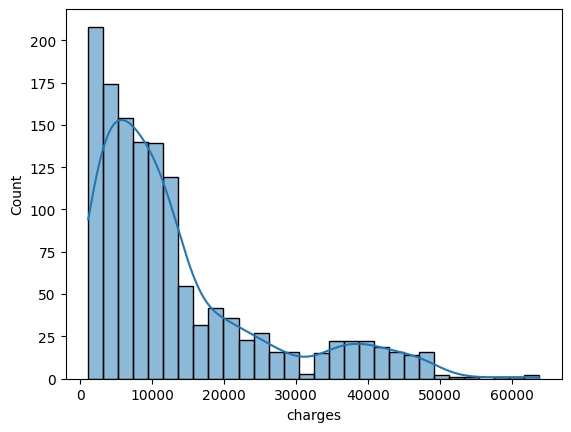

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# Histograma con curva de densidad
sns.histplot(df["charges"], kde=True)

# Ajuste de distribución normal
mu, sigma = norm.fit(df["charges"])
print(mu, sigma)

- **¿La distribución se parece a una normal?**
La dristribucion no se asemeja a una normal
- **¿Existen valores extremos que afecten la forma de la distribución?**
Si, tanto los delinicio como los del final
- **¿Qué interpretación darías a la forma del histograma?**
La frecuencia disminuye conforme la cifra es mayor

# 4. Comparación entre categorías

En esta sección analizarás cómo varía una variable numérica cuando se agrupa por categorías.

**Instrucciones:**
1. Selecciona una variable numérica (ejemplo: `charges` o `bmi`).
2. Compárala entre diferentes categorías, como:
   - `smoker` (fumador / no fumador)
   - `sex` (hombre / mujer)
   - `region` (norte, sur, este, oeste)
3. Usa gráficos adecuados para comparar distribuciones entre grupos.

**Preguntas de referencia:**
- ¿Se observan diferencias claras en la media o dispersión de los grupos?
- ¿Qué grupo muestra más variabilidad en la variable numérica?
- ¿Qué categorías parecen tener un comportamiento más homogéneo?

**Sugerencias de código:**
```python
# Boxplot
sns.boxplot(x="smoker", y="charges", data=df)

# Violinplot
sns.violinplot(x="sex", y="bmi", data=df)

# Comparación por región
sns.boxplot(x="region", y="charges", data=df)


<Axes: xlabel='smoker', ylabel='Count'>

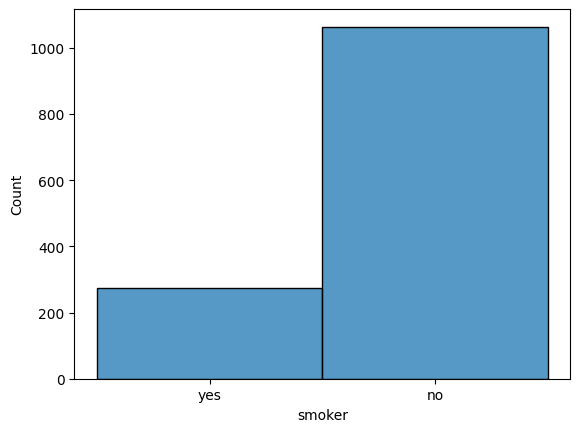

In [21]:
#Grafica de frecuencia de fumadores
sns.histplot( x="smoker" ,data=df)

<Axes: xlabel='region', ylabel='charges'>

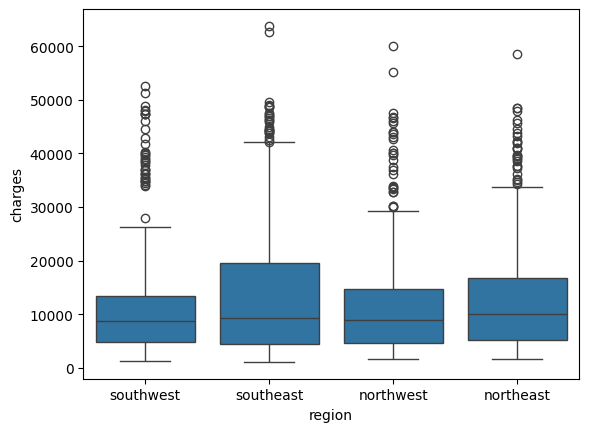

In [22]:
# Comparación por región
sns.boxplot(x="region", y="charges", data=df)

# 5. Resumen estadístico por grupos

En esta sección calcularás estadísticas descriptivas para una variable numérica, agrupando según una variable categórica.

**Instrucciones:**
1. Elige una variable numérica, por ejemplo `charges` o `bmi`.
2. Agrúpala por una variable categórica como `smoker`, `sex` o `region`.
3. Calcula medidas de tendencia central y dispersión:
   - Media
   - Desviación estándar
   - Mínimo y máximo

**Preguntas de referencia:**
- ¿Qué grupos presentan mayor costo promedio (`charges`)?
- ¿Existen diferencias notables en la dispersión de los valores?
- ¿Qué categorías parecen tener valores más homogéneos?

**Sugerencias de código:**
```python
# Resumen por grupo
df.groupby("smoker")["charges"].describe()

# Media y desviación estándar por sexo
df.groupby("sex")["bmi"].agg(["mean", "std"])

# Mínimo y máximo por región
df.groupby("region")["charges"].agg(["min", "max"])


In [27]:
#resumen de la region
print(df.groupby("region")["charges"].describe())
#minimo y maximo por grupo
print(df.groupby("smoker")["charges"].agg(["min", "max"]))
# Media y desviación estándar por region
print(df.groupby("region")["bmi"].agg(["mean", "std"]))

           count          mean           std        min          25%  \
region                                                                 
northeast  324.0  13406.384516  11255.803066  1694.7964  5194.322288   
northwest  325.0  12417.575374  11072.276928  1621.3402  4719.736550   
southeast  364.0  14735.411438  13971.098589  1121.8739  4440.886200   
southwest  325.0  12346.937377  11557.179101  1241.5650  4751.070000   

                    50%         75%          max  
region                                            
northeast  10057.652025  16687.3641  58571.07448  
northwest   8965.795750  14711.7438  60021.39897  
southeast   9294.131950  19526.2869  63770.42801  
southwest   8798.593000  13462.5200  52590.82939  
               min          max
smoker                         
no       1121.8739  36910.60803
yes     12829.4551  63770.42801
                mean       std
region                        
northeast  29.173503  5.937513
northwest  29.199785  5.136765
southeast

# 6. Transformaciones de variables

En esta sección aplicarás transformaciones a una variable numérica para mejorar su comportamiento estadístico y su ajuste a distribuciones teóricas.

**Instrucciones:**
1. Selecciona una variable numérica sesgada, por ejemplo `charges`.
2. Grafica su histograma original.
3. Aplica una transformación logarítmica (`np.log`) sobre la variable.
4. Vuelve a graficar el histograma de la variable transformada.
5. Compara ambas gráficas y comenta si la transformación mejora el ajuste a la normalidad.

**Preguntas de referencia:**
- ¿La variable transformada se parece más a una distribución normal?
- ¿Qué pasa con los valores extremos después de la transformación?
- ¿Por qué puede ser útil aplicar este tipo de transformaciones en modelos estadísticos?

**Sugerencias de código:**
```python
import numpy as np

# Histograma original
sns.histplot(df["charges"], kde=True)

# Transformación logarítmica
df["log_charges"] = np.log(df["charges"])

# Histograma transformado
sns.histplot(df["log_charges"], kde=True)


<Axes: xlabel='bmi', ylabel='Count'>

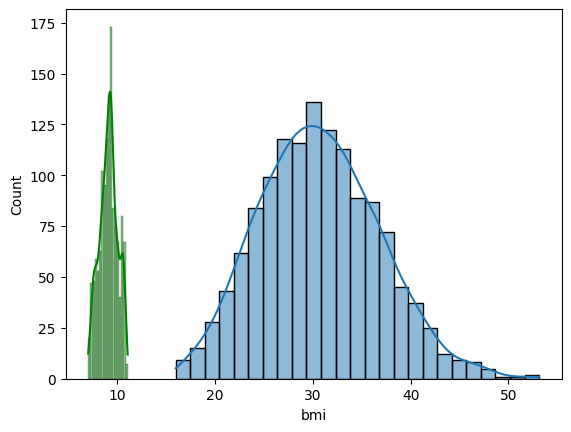

In [31]:
import numpy as np

# Histograma original
sns.histplot(df["bmi"], kde=True)

# Transformación logarítmica
df["log_bmi"] = np.log(df["charges"])

# Histograma transformado
sns.histplot(df["log_bmi"], kde=True, color = "GREEN")


# 7. Conclusiones

En esta última sección debes redactar un breve análisis con base en los resultados obtenidos en las secciones anteriores.

**Instrucciones:**
1. Resume los hallazgos principales de tu análisis.
2. Destaca las diferencias encontradas entre grupos (ej. fumadores vs no fumadores).
3. Menciona qué variables parecen influir más en los costos médicos (`charges`).
4. Comenta sobre el efecto de la transformación logarítmica: ¿mejoró la distribución?
5. Explica brevemente por qué estos pasos (limpieza, exploración, comparación y transformación) son importantes antes de aplicar un modelo de Machine Learning.

**Preguntas de referencia:**
- ¿Qué descubriste sobre la distribución de los costos médicos?
- ¿Qué variables categóricas mostraron mayor impacto en las variables numéricas?
- ¿Qué aprendiste al comparar los datos con distribuciones teóricas?
- ¿Qué ventajas tiene trabajar los datos de esta forma antes de modelar?

**Sugerencias**
- Usa párrafos cortos, claros y en tus propias palabras.
- Puedes incluir una lista de puntos clave.
- Asegúrate de responder en base a las preguntas de referencia con base en tus gráficos y cálculos.


**1. Hallazgos clave sobre la distribución de `charges` y su comparación con una distribución normal:**

La distribución de la variable `charges` (costos médicos) presenta un fuerte sesgo positivo, es decir, está cargada hacia la izquierda con una larga cola hacia la derecha. Esto significa que la mayoría de los costos médicos son bajos, pero existen algunos casos con costos muy elevados que alargan la distribución. Al compararla con una curva de distribución normal, es evidente que los datos no siguen dicha distribución.

**2. Variables con una relación más fuerte con los costos médicos:**

Del análisis exploratorio, se observa que las siguientes variables tienen una relación importante con los costos médicos:
* **`smoker` (fumador):** Es la variable con el impacto más significativo. Los diagramas de caja y bigotes muestran que los costos médicos para los fumadores son considerablemente más altos que para los no fumadores.
* **`age` (edad):** Existe una correlación positiva. El diagrama de dispersión indica que a medida que la edad aumenta, los costos médicos también tienden a incrementarse.
* **`bmi` (índice de masa corporal):** También parece tener una correlación positiva con los costos, aunque la relación no es tan marcada como en el caso de ser fumador o la edad.

**3. Utilidad de la probabilidad y las distribuciones teóricas:**

El uso de distribuciones teóricas como la normal fue fundamental para evaluar las características de la variable `charges`. Permitió cuantificar y visualizar de manera clara que los datos no se comportaban de manera "normal", lo cual es un supuesto importante para muchos modelos estadísticos y de machine learning. Entender la distribución real de los datos es el primer paso para saber cómo tratarlos y qué modelos pueden ser más adecuados.

**4. Efecto de la transformación logarítmica:**

La transformación logarítmica aplicada a la variable `bmi` fue muy efectiva. El histograma de los datos transformados (`log_bmi`) muestra una distribución mucho más simétrica y cercana a una distribución normal, reduciendo significativamente el sesgo que se observó en los datos originales.

**5. Importancia de la limpieza, exploración y transformación de datos:**

Estos pasos son cruciales antes de construir un modelo de Machine Learning por las siguientes razones:
* **Limpieza de datos:** Asegura la calidad y fiabilidad de los datos. Errores como valores nulos o duplicados (como el que se encontró en el notebook) pueden generar resultados incorrectos y modelos sesgados.
* **Exploración de datos:** Permite descubrir patrones, relaciones entre variables y anomalías. Este conocimiento es vital para seleccionar las variables correctas (ingeniería de características) y el tipo de modelo a utilizar.
* **Comparación y transformación:** Ayuda a que los datos cumplan con los supuestos de los modelos. Muchos algoritmos funcionan mejor cuando las variables (o los errores del modelo) siguen una distribución normal. La transformación de datos, como la logarítmica, es una técnica clave para mejorar el rendimiento y la precisión del modelo final.